# Tutorial: Graph Neural Networks (GNN)
> Created Aug. 2024 for the FSU Course: *Machine Learning in Physics* <br>
> Updated: Wed Sep 24 2025: Adapted for Introduction to ML course at AIMS South Africa<br>
> Harrison B. Prosper<br>


## Introduction
In this tutorial we build a **graph neural network** (GNN) similar to the one developed in the award-winning work by the IceCube Collaboration[1] which yielded state-of-the-art results in neutrino event classification.
Our goal is to classify events as **signal** or **background**, where each event is modeled as a list of data pertaining to particles: the transverse momentum of a particle, $p_T$ and its direction $(\eta, \phi)$. The quantity $\eta = -\log\tan (\theta/2)$ is the pseudo-rapidity, $\theta$ the polar angle, and $\phi$ the azimuthal angle.

In mathematics, a **graph** is a tuple $G = (V, E)$ of two sets $V = \{v_1,\cdots\}$ and $E = \{e_1,\cdots\}$ where $V$ is a set of **vertices** (or nodes) connected by **edges** that form a set $E$.
Graphs are closely related to **point clouds**, which is literally a cloud of points in some vector space. In this tutorial, each data instance, that is, event, is a point cloud $P = \{ (p_T, \eta, \phi)_i \}_{i=0}^{n-1} \in \mathbb{R}^d$, where $d = 3$ and where, in general, the number of points $n$, that is, particles, varies from one point cloud to the next. The subset of data used in this tutorial come from the website [LHC Olympics 2020](https://lhco2020.github.io/homepage/), which you should consult for a detailed description of the particle collision events.

Because the number of points varies from one point cloud to the next, we shall train the GNN with a batch size of one. PyTorch provides a rather large flexible, sophisticated, efficient toolkit called PyTorch Geometric for building many different kinds of graph. But the purpose of this tutorial is to expose all the details of a simple specific type of GNN, namely, a **Graph Convolutional Network** (GCN).
<br clear="left"/>

## References
  1. N. Choma et al. IceCube collaboration, Graph Neural Networks for IceCube Signal Classification,  arXiv:1809.06166v1.

## Tips

  * Use __esc r__ to disable a cell
  * Use __esc y__ to reactivate it
  * Use __esc m__ to go to markdown mode. **Markdown** is the typesetting language used in jupyter notebooks.
  * In a markdown cell, double tap the mouse or glide pad (on your laptop) to go to edit mode.
  * Shift + return to execute a cell (including markdown cells).
  * If the equations don't typeset, try double tapping the cell again, and re-execute it.

## Installation of `mlinphysics`

### Local installation
  ```bash
      git clone https://github.com/hbprosper/mlinphysics
      cd mlinphysics
      pip install -e .
  ```

In [1]:
COLAB_FOLDER = 'MLP/06.GNN/code' # change as needed
GITHUB_USER  = 'hbprosper'
GITHUB_REPO  = 'mlinphysics'
GITHUB_FOLDERS = ['mlinphysics']
#------------------------------------------------------
try:
    from google.colab import drive
    drive.mount('/content/gdrive')
    print('\nGoogle Drive mounted\n')
    IN_COLAB = True
except:
    print('\nRunning locally\n')
    IN_COLAB = False
 
if IN_COLAB:
    MYDRIVE      = '/content/gdrive/MyDrive'
    GITHUB_BASE  = 'https://raw.githubusercontent.com'
    GITHUB_PATH  = f'{MYDRIVE}/{COLAB_FOLDER}'
    MAIN         = 'refs/heads/main'
    
    %cd {GITHUB_PATH}
    %rm -f {GITHUB_PATH}/clone2colab.ipynb
    !wget -q {GITHUB_BASE}/{GITHUB_USER}/{GITHUB_REPO}/{MAIN}/clone2colab.ipynb
    %run {GITHUB_PATH}/clone2colab.ipynb


Running locally



# PART 1

In [2]:
# standard system modules
import os, sys

# standard module for tabular data
import pandas as pd

# standard module for array manipulation
import numpy as np

# module to access data in Hierarchical Data Format (HDF or H5 format)
import h5py

# to reimport Python modules
import importlib

# standard module for high-quality plots
import matplotlib as mp
import matplotlib.pyplot as plt

# standard research-level machine learning toolkit from Meta (FKA: FaceBook)
import torch
import torch.nn as nn
import torch.nn.functional as F

import networkx as nx

# module to reimport Python modules
import importlib

# module for shell utilities
import shutil

# ML in physics module
import mlinphysics.nn as mlp
import mlinphysics.utils.data as dat
import mlinphysics.utils.monitor as mon
import mlinphysics.utils.tutorials as tut

from tqdm import tqdm

# update fonts
if not IN_COLAB:
    usetex = shutil.which('latex') is not None
    
    plt.rcParams.update({
      "text.usetex": usetex,
      "font.family": "sans-serif",
      "font.sans-serif": "Helvetica",
      "font.size": 14
  })

## Computational device

In [3]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\n\tAvailable device: {str(DEVICE):4s}\n')


	Available device: cpu 



## Load Events
The dataset comprises 36,000 events divided equally between signal and background that have been randomly shuffled. The targets can be accessed using the key 'targets' and an event is accessed by specifying the event number  'N', with the first event being '0'.

In [5]:
events, targets = tut.load_events('../data/events.h5', pTcut=0.5)

targets.shape, events[0].shape, events[1].shape

100%|██████████████████████████████████| 36000/36000 [00:03<00:00, 10041.06it/s]



	sample size:             36000
	min(multiplicity):          29
	max(multiplicity):         529
	E[pT]:                      23.4 GeV
	E[multiplicity] +/-std:    148.3 +/-50.1    


((36000,), (107, 3), (128, 3))

## Plot Events

The particle's transverse momentum is proportional to the area of the markers.

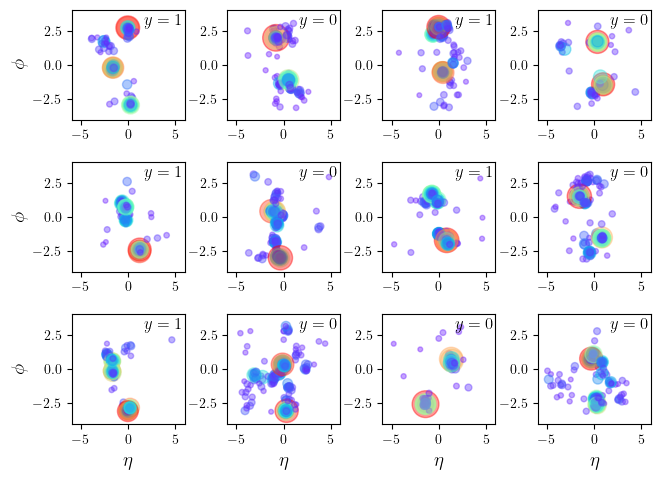

In [6]:
tut.plot_events(events, targets)

## Configuration

In [7]:
# name of model
# -----------------------------------------
name = 'sigbkg'

# choose whether to create or load a configuration file
load_existing_config = False

if load_existing_config:
    config = mlp.Config(f'{name}.yaml')
else:
    # create new configuration
    config = mlp.Config(name)

    # training configuration
    # -----------------------------------------
    config('train_size', 32_000)  # training sample size
    config('test_size',   3_900)  # test sample size
    config('val_size',      100)  # validation sample size
    config('batch_size',      1)  # must be one!
    config('monitor_step',  100)  # monitor training every n (=10) iterations
    config('delete', True)        # delete losses file before training, if True
    config('frac', 0.015)         # save model if average loss decreases by more
                                  # than frac percent

    # optimizer / scheduler configuration
    # -----------------------------------------
    # a step comprises a given number of iterations
    config('n_steps', 4)                # number of training steps
    config('n_iters_per_step', config('train_size'))
    config('base_lr', 2.e-3)            # initial learning rate
    config('gamma', 0.5)                # learning rate scale factor
    print(f'\nSave configuration to file {config.cfg_filename}\n')

    config.save()

# add number of iterations
config('n_iterations',
       config('n_iters_per_step') * \
       config('n_steps'))

print(config)


Save configuration to file runs/2025-10-25_2239/sigbkg_config.yaml

name: sigbkg
file:
  losses: runs/2025-10-25_2239/sigbkg_losses.csv
  params: runs/2025-10-25_2239/sigbkg_params.pth
  init_params: runs/2025-10-25_2239/sigbkg_init_params.pth
  plots: runs/2025-10-25_2239/sigbkg_plots.png
train_size: 32000
test_size: 3900
val_size: 100
batch_size: 1
monitor_step: 100
delete: true
frac: 0.015
n_steps: 4
n_iters_per_step: 32000
base_lr: 0.002
gamma: 0.5
n_iterations: 128000



## Prepare datasets and dataloaders
  1. Scale data.
  2. Build an inhomogeneous `numpy` array of events. Why?
  3. Split data into training, testing, and validation sets.

### Create Custom Datasets

In [8]:
#                      pT, eta,   phi
scale = torch.Tensor([[50,   5, np.pi]])

sevents = [event / scale for event in events]

type(sevents), type(sevents[0]), sevents[0].device, targets.dtype

(list, torch.Tensor, device(type='cpu'), dtype('int64'))

In [9]:
importlib.reload(dat)

train_size = config('train_size')
val_size   = config('val_size')
test_size  = config('test_size')

# change type of targets from long to float (need for nn.BCELoss)
targets = targets.astype(np.float32)

# training dataset (this defines the empirical risk to be minimized)
print('training data')
train_data = dat.Dataset(sevents,
                         start=0,
                         end=train_size,
                         targets=targets)

# a random subset of the training data to check for overtraining
# by comparing with the empirical risk from the validation set
print('training data for validation')
train_data_val = dat.Dataset(sevents,
                             start=0,
                             end=train_size,
                             targets=targets,
                             random_sample_size=val_size)

# validation dataset (for monitoring training)
print('validation data')
val_data = dat.Dataset(sevents,
                       start=train_size,
                       end=train_size + val_size,
                       targets=targets)

# test dataset
print('test data')
test_data= dat.Dataset(sevents,
                       start=train_size + val_size,
                       end=train_size + val_size + test_size,
                       targets=targets)

training data
Dataset
  shape of x: 32000
  shape of y: 32000

training data for validation
Dataset
  shape of x: 100
  shape of y: 100

validation data
Dataset
  shape of x: 100
  shape of y: 100

test data
Dataset
  shape of x: 3900
  shape of y: 3900



### DataLoaders

In [10]:
import torch.utils.data as td

print('train data loader')
train_loader = td.DataLoader(train_data, batch_size=config('batch_size'))

print('train data loader for validation')
train_loader_val = td.DataLoader(train_data_val, batch_size=config('batch_size'))

print('validation data loader')
val_loader = td.DataLoader(val_data, batch_size=config('batch_size'))

print('test data loader')
test_loader = td.DataLoader(test_data, batch_size=config('batch_size'))

train data loader
train data loader for validation
validation data loader
test data loader


## Build Model

### $\texttt{IceCubeAdjacencyMatrix}$
This class computes the adjacency matrix $A$ given vertices $V$. An event with $n$ particles can be modeled as a graph with $n$ vertices. Inspired by IceCube, we model the edges of the graph as an $n \times n$ adjacency matrix $A$ where the matrix elements are given by
\begin{align}
    d_{ij} & = \exp(-\alpha \| x_i - x_j \|^2), \\
    A_{ij} & = \texttt{softmax}(d_{ij}, \, \texttt{dim}=1) ,
\end{align}
where $x_i = (\eta_i, \phi_i)$ and $\alpha$ is a free parameter. Following IceCube, the adjacency matrix is not changed by the graph convolution operation, but does of course change from one graph to the next.

Since the maximum number of particles is less than about 400 with the median of about 160, it is still feasible to construct $n \times n$ matrices. For much larger $n$ one would have to use sparse matrix representations of the adjacency matrix. The $-1$ in a given tensor dimension indicates that the number of elements in that dimension is determined at runtime. In this example, that number will be the number of particles $n$.

#### A note on array broadcasting
**Broadcasting** is a powerful mechanism that makes it possible to perform many useful array or tensor manipulations. The $\texttt{IceCubeAdjacencyMatrix}$ class uses broadcasting to compute all possible $\eta$ and $\phi$ differences $\Delta \eta_{ij} = \eta_i - \eta_j$ and $\Delta \phi_{ij} = \phi_i - \phi_j$ between the $n$ particles.  By changing the shapes of the tensors $\texttt{eta}$ and $\texttt{phi}$ using $\texttt{view(-1, n, 1)}$ and $\texttt{view(-1, 1, n)}$, that is, by changing their shapes to a tensor containing a single column and a tensor containing a single row, respectively, all possible $\eta$ and $\phi$ differences can be computed. (The -1 in the  $\texttt{dim}=0$ position of $\texttt{view}$ is the batch size, which here is 1 and determined at runtime.)

Conceptually, what happens is this. The single-column tensor constructed using $\texttt{view(-1, n, 1)}$ is  replicated to form a tensor of shape $(-1, n, n)$ in which every ''column'' is identical.  Likewise, the single-row tensor constructed using $\texttt{view(-1, 1, n)}$ is replicated to form a tensor of shape $(n, n)$ in which every row is identical. Now that the tensors are of the same shape, an elementwise subtraction is performed on the two $n \times n$ tensors, resulting in 2D tensors of shape $(n, n)$ containing all possible differences. Of course, the actual implementation is much more efficient than this!

In [11]:
class IceCubeAdjacencyMatrix(nn.Module):
    '''
    Given a set of vertices V, compute the adjacency matrix of shape (n, n).
    '''
    def __init__(self, alpha=1):

        super().__init__()

        # Note use of Parameter to tell PyTorch that the parameter
        # alpha is to be fitted.
        self.alpha = nn.Parameter(alpha * torch.rand(1))

    def forward(self, x):
        # shape of tensor x: (batch size, number of particles, number of attributes)
        _, size, d = x.shape

        # 1. compute square of Euclidean distance in (eta, phi) space
        #    dR^2 = deta^2 + dphi^2
        eta, phi = x[:, :, 1], x[:, :, 2]

        # use broadcasting to compute all possible differences
        deta = eta.view(-1, size, 1) - eta.view(-1, 1, size)
        dphi = tut.delta_phi(phi.view(-1, size, 1), phi.view(-1, 1, size))
        dRdR = deta**2 + dphi**2

        # 2. compute exp(- alpha * dR)**2)
        A = torch.exp(-self.alpha * dRdR)

        # 3. apply softmax in "horizontal" direction.
        #    adding a unit matrix to the adjacency matrix
        #    makes the training more stable. we need to send
        #    the unit matrix to the same computatational device as used by A.
        A = torch.softmax(A, dim=-1) # + torch.eye(size).to(A.device)
        return A

## Plot as graphs

number of particles with pT > 4 GeV:  159
number of particles with pT > 4 GeV:  226
number of particles with pT > 4 GeV:   70
number of particles with pT > 4 GeV:  144


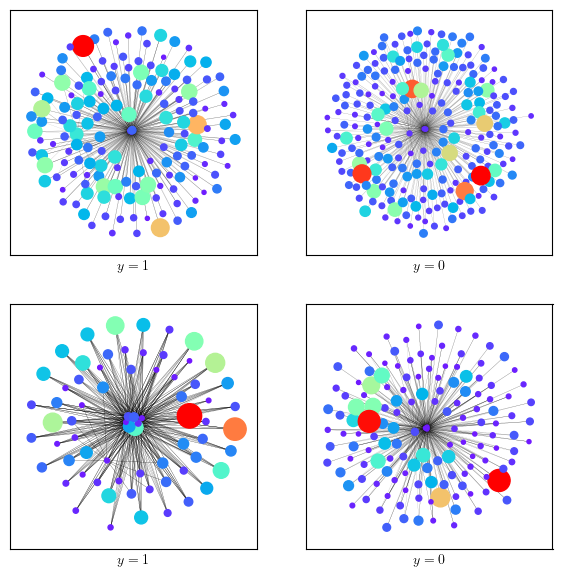

In [12]:
def plot_graphs(loader, ptscale=25, scale=80,
                xmin=-6.0, xmax=6.0,
                ymin=-4.0, ymax=4.0,
                filename='events_as_graphs.png',
                ftsize=14):

    plt.rcParams.update({'font.size': 10})

    # work out number of columns and number of plots
    ncols = 2
    nrows = 2
    ndata = ncols * nrows
    fgsize= (7, 7)
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=fgsize)
    
    axs = axs.flatten()
    
    gedge = IceCubeAdjacencyMatrix()
    
    # loop over number of point clouds, ndata
    for i, (event, y) in enumerate(loader):
        if i > ndata-1: break

        ax = axs[i]

        ax.set_xlabel(f'$y = {int(y.detach()):d}$')
        
        # get point cloud (i.e., event).
        # area of points in (eta, phi) proportional to pT of particle
        
        pt, eta, phi = event[0,:,:].detach().numpy().T[:]
        y = y.detach().numpy()[0]
        evt = event.squeeze().view(-1,len(pt), 3)
        A   = gedge(evt).squeeze()

        print(f'number of particles with pT > 4 GeV: {len(pt):4d}')
        
        size = scale * np.sqrt(pt / ptscale)
        cmap = mp.colormaps['rainbow']
        colors = cmap(size / size.max(), alpha=1)

        # create a graph
        G = nx.Graph()
        n = 0
        widths = []
        for j in range(len(pt)):
            G.add_node(j, value=pt[j])
            for k in range(len(pt)):
                if k == j: continue
                w = float(A[j, k].detach())
                n += 1
                if n < 500:
                    G.add_edge(j, k, weight=w)
                    widths.append(10*w)
                    
        widths = np.array(widths)

        # Position nodes
        pos = nx.spring_layout(G, seed=42)

        # Draw the graph
        nodes = nx.draw_networkx_nodes(G, pos, 
                                       node_size=5*size, 
                                       node_color=colors, ax=ax)
        
        edges = nx.draw_networkx_edges(G, pos, 
                                       width=widths, ax=ax)
        plt.plot()

    #fig.tight_layout()
    plt.savefig(filename)

plot_graphs(val_loader)

### Graph Convolution: $\texttt{GNNConv}$
We implement a simple graph convolutional layer from scratch, which differs from the one implemented by IceCube.
As in most GNNs, the nodes (aka vertices) are concatenated into a matrix, $X$, of shape $(n, d)$. Given a weight matrix $w$ of shape $(h, h)$, where generally $h > d$, and a matrix of ones of shape $(n, h)$ scaled by the bias parameter $b$, the graph convolution operation is defined by
\begin{align}
    X & = \sigma(X W_0^T + B_0), \text{ embedding}\\
    X^\prime & = A X, \text{ attention} \\
    Z & = X^\prime W_1^T + B_1 ,
\end{align}
that is, a linear function that maps the nodes of $X$ to a vector in an embedding space of dimension $h$, thereby yielding a matrix of shape $(n, h)$. Then a nonlinear operation, $\sigma(*)$, is applied (usually, element wise) to every element of the embedded vectors. This is followed by another linear function involving the adjacency matrix, $A$, which is then subject to another nonlinear operation.

For each node, the matrix operation $A X$ assigns weights to the nearest neighbors of a given vertex.  Following the IceCube model, for a given node all other nodes are its neighbors. However, the closer neighbors are weighted more than those further away. The tunable parameter $\alpha$ in the adjacency matrix $A$ determines the scale of the nearest neighbor domains. This is a simple example of a so-called **attention** mechanism. Finally, a linear operation is applied to the **attention** tensor $AX$.

In [13]:
class GNNConv(nn.Module):

    def __init__(self, in_features, out_features, scale=0.05):

        # initialize base class
        super().__init__()

        # we embed the "n" input vertices in a larger vector space
        # of dimension h = out_features
        self.embed  = nn.Linear(in_features, out_features)
        self.linear = nn.Linear(out_features, out_features)

    def forward(self, X, A):

        # embed vertices in a larger vector space
        X = self.embed(X) # output shape (n, h)
        X = F.relu(X)
        
        # assign weights to the neighbors of each vertex,
        # weighting the nearest neighbors more heavily.
        # AX = A * X
        AX = torch.matmul(A, X)  # output shape (n, h)

        # compute (A * X) * W + B
        X = self.linear(AX)
        
        # return modified vertices
        return X

class InvariantFunction(nn.Module):
    '''
    Perform a permutation and vertex count-invariant operation on the
    vertices of a graph.
    '''
    def __init__(self):
        super().__init__()

    def forward(self, x):
        m = x.mean(dim=1)
        return m

### Build graph neural network (GNN)

In [14]:
class GNN(mlp.Model):

    def __init__(self, n_dim=3, n_embed=40, dropout=0.5):

        # initialize base class
        super().__init__()

        self.edges  = IceCubeAdjacencyMatrix()
        self.gconv1 = GNNConv(n_dim,   n_embed)
        self.gconv2 = GNNConv(n_embed, n_embed)
        self.invfun = InvariantFunction()
        self.linear = nn.Linear(n_embed, 1)
        self.dropout= nn.Dropout(dropout)

    def forward(self, x):
        # construct n x n adjacency matrix which together
        # with the nodes V = x forms the graph G = (V, A)
        V = x
        A = self.edges(V)
        
        # pass graph G = (V, A) through multiple
        # graph convolution layers (graph processors)
        V = self.gconv1(V, A)
        V = F.relu(V)
        V = self.dropout(V)

        V = self.gconv2(V, A)
        V = F.relu(V)
        V = self.dropout(V)

        # apply a permutation- and vertex count-invariant
        # function to the nodes
        x = self.invfun(V)

        # complete with a simple MLP
        x = self.linear(x)
        x = F.sigmoid(x)

        return x

## Instantiate training objects
  1. `model`
  2. `optimizer`
  1. `scheduler`
  1. `objective`

In [15]:
importlib.reload(mlp)

model = GNN().to(DEVICE)
print('number of parameters:', mlp.number_of_parameters(model))
print(model)
print()

print('Parameters\n')
for name, p in model.named_parameters():
    if p.requires_grad:
        print(name)
print()

optimizer = torch.optim.Adam(model.parameters(), lr=config('base_lr'))

scheduler = mlp.get_steplr_scheduler(optimizer, config)

objective = mlp.Objective(model, nn.BCELoss())

number of parameters: 5122
GNN(
  (edges): IceCubeAdjacencyMatrix()
  (gconv1): GNNConv(
    (embed): Linear(in_features=3, out_features=40, bias=True)
    (linear): Linear(in_features=40, out_features=40, bias=True)
  )
  (gconv2): GNNConv(
    (embed): Linear(in_features=40, out_features=40, bias=True)
    (linear): Linear(in_features=40, out_features=40, bias=True)
  )
  (invfun): InvariantFunction()
  (linear): Linear(in_features=40, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

Parameters

edges.alpha
gconv1.embed.weight
gconv1.embed.bias
gconv1.linear.weight
gconv1.linear.bias
gconv2.embed.weight
gconv2.embed.bias
gconv2.linear.weight
gconv2.linear.bias
linear.weight
linear.bias

number of milestones:          3

Step | Milestone | LR
-----------------------------
   0 |         0 | 2.0e-03   
-----------------------------
   1 |     32000 | 1.0e-03   
   2 |     64000 | 5.0e-04   
   3 |     96000 | 2.5e-04   

number of iterations:         128000



## Define trainer

In [16]:
importlib.reload(mlp)

def train(objective, optimizer, scheduler,
          train_loader, train_small_loader, val_loader,
          config):

    # get configuration info
    lossfile   = config('file/losses')
    paramsfile = config('file/params')
    monstep    = config('monitor_step')
    delete     = config('delete')
    frac       = config('frac')
    nepoch     = config('n_steps')

    # instantiate object that saves average losses to
    # a csv file for realtime monitoring

    number_iterations = len(train_loader) * nepoch

    losswriter = mon.LossWriter(number_iterations,
                                lossfile,
                                step=monstep,
                                delete=delete,
                                frac=frac,
                                model=objective.model,
                                paramsfile=paramsfile)

    # instantiate learning rate step scheduler
    lrscheduler = mlp.LRStepScheduler(optimizer, scheduler)

    # This is miserably slow, so use it sparingly
    def sloth(loader):
        R = torch.stack( [ objective(x, y) for x, y in loader ] ).mean()
        return R

    # -----------------------------
    # training loop
    # -----------------------------   
    for epoch in range(nepoch):
        
        for jj, (X, Y) in enumerate(train_loader):

            ii = jj + epoch * len(train_loader)
            
            # set mode to training so that training-specific
            # operations such as dropout, etc., are enabled.
            objective.train()
    
            # clear all gradients
            optimizer.zero_grad()
    
            R = objective(X, Y)
            
            # compute gradients
            R.backward()
    
            # take one step downhill in the empirical risk landscape
            optimizer.step()
    
            # check whether to update learning rate
            lrscheduler.step()
    
            # I'm alive printout
            if (ii % monstep == 0) or (ii == number_iterations-1):
    
                # compute average losses on training and validation data
                with torch.no_grad():
                    
                    # set mode to evaluation so that training-specific
                    # operations such as dropout, etc., are disabled.
                    objective.eval()
    
                    t_loss = float( sloth(train_loader_val).cpu() )
                    v_loss = float( sloth(val_loader).cpu() )
    
                # return current learning rate
                lr = lrscheduler.lr()
    
                # update loss file
                losswriter(ii, t_loss, v_loss, lr, epoch)


## Train Model


		learning rate:  2.000e-03
     31900| 24.92%|00:00:56/00:02:50| 563.4 it/s|         0|4.654e-01|3.719e-01|
		learning rate:  1.000e-03
     63900| 49.92%|00:01:47/00:01:47| 594.8 it/s|         1|4.576e-01|3.627e-01|
		learning rate:  5.000e-04
     95900| 74.92%|00:02:47/00:00:55| 573.9 it/s|         2|4.501e-01|3.647e-01|
		learning rate:  2.500e-04
    127999|100.00%|00:03:42/00:00:00| 575.5 it/s|         3|4.310e-01|3.657e-01|


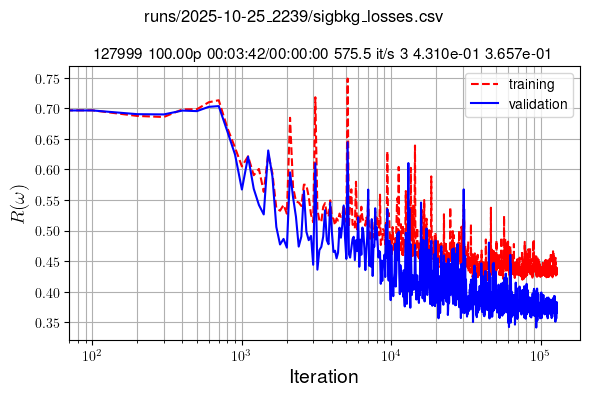

In [17]:
train(objective, optimizer, scheduler,
      train_loader, train_loader_val, val_loader,
      config)

monitor = mon.Monitor(config('file/losses'))
monitor.plot()

## Plot Results

  1. Confusion matrix for signals defined by $y \geq 1/2$.
  2. Classifier distribution $\hat{y} = D(G)$.
  3. ROC curve

**NB**: In the following codes, the first argument is always the targets $y$ and the second the model predictions $\hat{y}$.

In [18]:
def plot_confusion_matrix(y, y_pred, gfile='confusion_matrix.png'):
    from sklearn.metrics import confusion_matrix

    # Calculate the confusion matrix
    conf_matrix = confusion_matrix(y_true=y, y_pred=y_pred)

    # plot the confusion matrix 
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.matshow(conf_matrix, cmap=plt.cm.rainbow, alpha=0.4)

    # annotate each element of matrix with count
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            ax.text(x=j, y=i, s=conf_matrix[i, j],
                    va='center', ha='center', size='x-large')

    plt.xlabel('Predicted Labels', fontsize=16)
    plt.ylabel('True Labels', fontsize=16)
    plt.title(f'Confusion Matrix', fontsize=16)

    fig.tight_layout()
    plt.savefig(gfile)

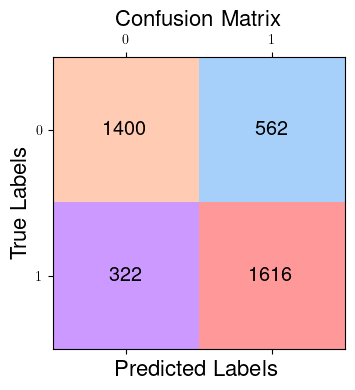

In [19]:
model.load(config('file/params'))

y_hat  = np.array([(float(model(x).detach().cpu()), 
                    float(y.detach().cpu())) for x, y in test_loader])
y_hat, y_true = y_hat.T
y_pred = (y_hat > 0.5).astype(int)

plot_confusion_matrix(y_true, y_pred)

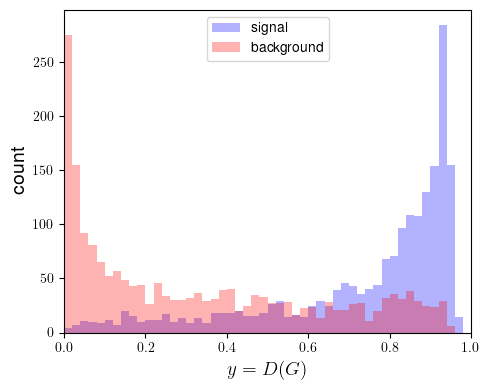

In [20]:
def plot_outputs(y, yhat,
                 xbins=50, xmin=0, xmax=1,
                 ymin=0, ymax=500,
                 filename='outputs.png',
                 fgsize=(5, 4),
                 ftsize=14):

    # create an empty figure
    fig = plt.figure(figsize=fgsize)

    nrows, ncols, index = 1, 1, 1
    ax = fig.add_subplot(nrows, ncols, index)

    # setup axes
    ax.set_xlim(xmin, xmax)
    #ax.set_ylim(ymin, ymax)

    ax.set_xlabel(r'$y = D(G)$', fontsize=ftsize)
    ax.set_ylabel(r'count', fontsize=ftsize)

    s = yhat[y > 0.5]
    b = yhat[y < 0.5]

    ax.hist(s, bins=xbins, range=(xmin, xmax), color='blue', alpha=0.3, label='signal')
    ax.hist(b, bins=xbins, range=(xmin, xmax), color='red', alpha=0.3, label='background')
    ax.legend()

    fig.tight_layout()
    plt.savefig(filename)

plot_outputs(y_true, y_hat)

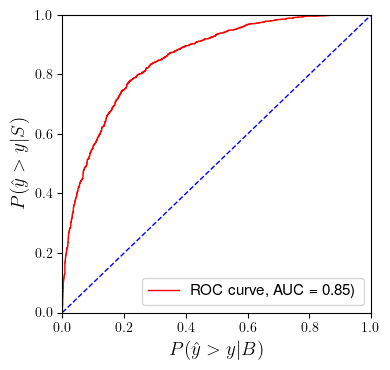

In [21]:
def plot_roc(y, yhat):
    # standard measures of model performance
    from sklearn.metrics import roc_curve, auc

    bkg, sig, _ = roc_curve(y, yhat)

    roc_auc = auc(bkg, sig)

    fig = plt.figure(figsize=(4.0, 3.8))

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('$P(\\hat{y} > y | B)$', fontsize=14)
    plt.ylabel('$P(\\hat{y} > y | S)$', fontsize=14)

    plt.plot(bkg, sig, color='red',
             lw=1, label='ROC curve, AUC = %0.2f)' % roc_auc)

    plt.plot([0, 1], [0, 1], color='blue', lw=1, linestyle='--')

    plt.legend(loc="lower right", fontsize=11)
    fig.tight_layout()
    plt.savefig("ROC.png")

plot_roc(y_true, y_hat)